In [2]:
%pip install networkx

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

business_df = pd.read_csv("../data/trustmesh_economic_data.csv")
business_df["month"] = pd.to_datetime(business_df["month"])

print("Dataset shape:", business_df.shape)
print("Unique businesses:", business_df["business_id"].nunique())

Dataset shape: (12000, 32)
Unique businesses: 500


In [4]:
# Use the latest economic state for each business
business_profiles = (
    business_df
    .sort_values("month")
    .groupby("business_id")
    .tail(1)
    .reset_index(drop=True)
)

# Create the knowledge graph
G = nx.Graph()

for _, row in business_profiles.iterrows():
    business = row["business_id"]
    business_type = row["business_type"]
    environment = row["environment_type"]
    location = row["location"]
    shock = row["shock_type"] if pd.notna(row["shock_type"]) else "No Shock"

    # Business node
    G.add_node(business, node_type="Business")

    # Related economic entities
    entities = {
        business_type: "Business Type",
        environment: "Environment",
        location: "Location",
        shock: "Economic Shock"
    }

    for entity, entity_type in entities.items():
        G.add_node(entity, node_type=entity_type)
        G.add_edge(business, entity, relationship={
            "Business Type": "BELONGS_TO",
            "Environment": "OPERATES_IN",
            "Location": "LOCATED_IN",
            "Economic Shock": "EXPERIENCES"
        }[entity_type])

print("Nodes:", G.number_of_nodes())
print("Relationships:", G.number_of_edges())

Nodes: 526
Relationships: 2000


In [5]:
# Analyze the most connected entities in the knowledge graph

node_summary = (
    pd.DataFrame(
        [
            {
                "node": node,
                "node_type": G.nodes[node]["node_type"],
                "connections": G.degree(node)
            }
            for node in G.nodes
        ]
    )
    .sort_values("connections", ascending=False)
)

print("Most connected entities:")
display(node_summary.head(15))

# Count relationships by type
relationship_summary = (
    pd.DataFrame(
        [
            {
                "relationship": data["relationship"],
                "count": 1
            }
            for _, _, data in G.edges(data=True)
        ]
    )
    .groupby("relationship")
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("\nRelationship distribution:")
display(relationship_summary)


Most connected entities:


,node,node_type,connections
4,No Shock,Economic Shock,407
11,Urban,Environment,175
2,Semi-Urban,Environment,125
22,Rural,Environment,125
10,Retail Shop,Business Type,100
6,Food Vendor,Business Type,80
19,Peri-Urban,Environment,75
26,Small Producer,Business Type,60
34,Transport Worker,Business Type,60
20,Delhi,Location,59



Relationship distribution:


,relationship,count
0,BELONGS_TO,500
1,EXPERIENCES,500
2,LOCATED_IN,500
3,OPERATES_IN,500


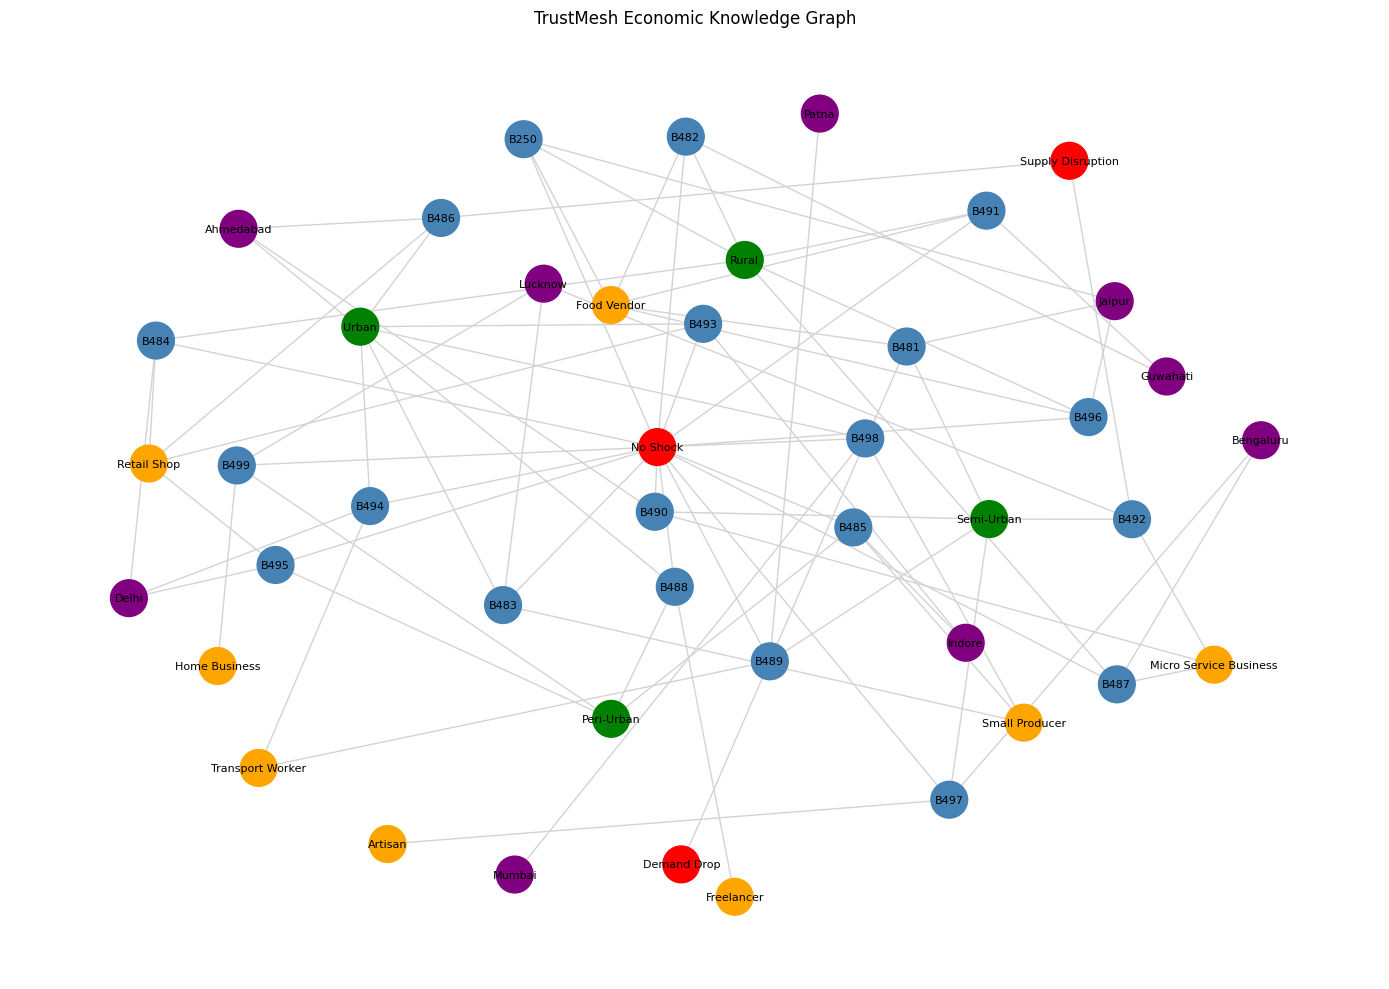

In [6]:
# Visualize a representative subgraph

sample_businesses = business_profiles["business_id"].head(20)

subgraph_nodes = set(sample_businesses)

for business in sample_businesses:
    subgraph_nodes.update(G.neighbors(business))

H = G.subgraph(subgraph_nodes)

plt.figure(figsize=(14, 10))

pos = nx.spring_layout(H, seed=42, k=1.2)

node_colors = []
for node in H.nodes:
    node_type = H.nodes[node]["node_type"]

    if node_type == "Business":
        node_colors.append("steelblue")
    elif node_type == "Business Type":
        node_colors.append("orange")
    elif node_type == "Environment":
        node_colors.append("green")
    elif node_type == "Location":
        node_colors.append("purple")
    else:
        node_colors.append("red")

nx.draw_networkx(
    H,
    pos,
    node_color=node_colors,
    node_size=700,
    font_size=8,
    edge_color="lightgray",
    with_labels=True
)

plt.title("TrustMesh Economic Knowledge Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

## Economic Knowledge Graph Findings

The Economic Knowledge Graph represents relationships between businesses and their surrounding economic context.

The graph contains **526 nodes** and **2,000 relationships**, representing 500 businesses connected to their business type, operating environment, location, and current economic shock state.

Four relationship types were established:

- **BELONGS_TO** — connects businesses to their business type
- **OPERATES_IN** — connects businesses to their environment type
- **LOCATED_IN** — connects businesses to their geographic location
- **EXPERIENCES** — connects businesses to their current economic shock state

The graph provides a structured representation of the economic ecosystem surrounding each business. This structure can later support relationship-based analysis, recommendation generation, and explainable decision-making within TrustMesh AI.

The current visualization shows a representative subset of businesses and their connected economic entities for readability. The complete graph remains available for computational analysis.